In [1]:
# auto reload 
%load_ext autoreload
%autoreload 2

In [2]:
import os

In [3]:
print(os.getcwd())

/home/nadav/dev/PhoCoLens/SVDeconv


In [4]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from PIL import Image
from sacred import Experiment
import cv2
import torch

In [5]:
from models.fftlayer_diff import FFTLayer_diff,load_psf
from config_diffusercam import initialise
from utils.tupperware import tupperware
from dataloader import get_dataloaders
from utils.ops import rggb_2_rgb, unpixel_shuffle
from utils.model_serialization import load_state_dict
from datasets.diffusercam import get_files_list_all_datasets,get_files_list_from_dir,LenslessLearning


In [6]:
from SRIL_utils.plot_utils import myim,plot_image_histogram,plot_hist

In [ ]:
image_dir = Path("/mnt/extra/traning_datasets/lenless_simulated/diff_psf_zvi2_8bit/train")
normalize_val = 2**15
psf_path = image_dir / 'psf.tiff'
suffix='.tiff'
psf_path.exists()

True

In [ ]:
image_dir = Path("/mnt/extra/traning_datasets/lenless_simulated/diffuser_0.4_bl_270/train")
normalize_val = 2**15
psf_path = image_dir / 'psf.npy'
suffix='.tiff'
psf_path.exists()

True

In [ ]:
image_dir = Path("/mnt/extra/traning_datasets/lenless_simulated/diffuser_images/train/")
normalize_val = 2**15
psf_path = image_dir / 'psf.tiff'
working_size = (270,480)
suffix='.tiff'
psf_path.exists()

True

In [70]:
image_dir = Path("/mnt/extra/traning_datasets/lensless/dataset/")
normalize_val = 2**15
psf_path = image_dir / 'psf.tiff'
working_size = (270,480)
suffix='.npy'
psf_path.exists()
dataset_name = ''#'diffuser'#'RAISE'
diffused_dir = 'diffuser_images'
gt_dir='ground_truth_lensed'

In [ ]:
dataset_name = 'RAISE'#'diffuser'#'RAISE'
diffused_dir = 'diffused'
gt_dir='gt_tiff'




In [107]:
image_dir = Path('/mnt/rnd/Nadav/lensless/lab/6.7.26/')
#psf_path = image_dir / 'psf' /'psf_100mu_1m_g5_exp_31.bmp'
psf_path = image_dir / 'psf' /'psf_100mu_1m_g14.bmp'

working_size = (600,800)#(3000,4000)#
normalize_val = 256

In [143]:
image_dir = Path('/mnt/rnd/Research/Lenless/Lab set up image collection/image capture/')
#psf_path = image_dir / 'psf_100mu_1m_g5_exp_31.bmp'
psf_path = image_dir / 'psf_100um_16bit_5_g3.8.bmp'

working_size = (600,800)#(3000,4000)#
normalize_val = 256
psf_path.exists()


True

In [145]:
p = cv2.imread(psf_path)

In [146]:
p.max()

np.uint8(255)

[(<Axes: >, <Axes: >)]

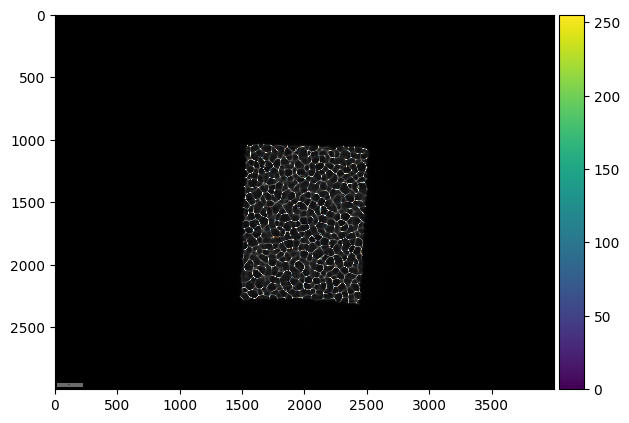

In [147]:
myim(p,colorbar=True)

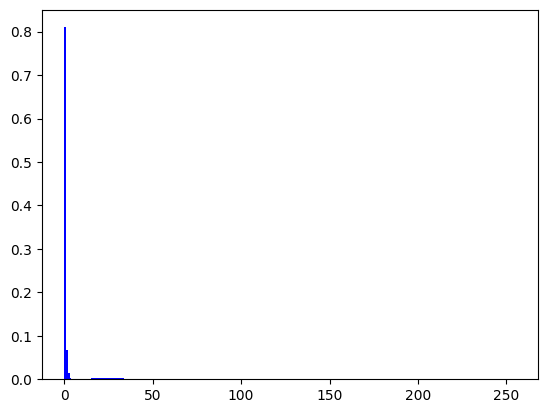

In [148]:
h,x=plot_hist(p,bins=255)

In [149]:
FFT=FFTLayer_diff.init_from_psf(psf_path,gamma=100,normalize_val=normalize_val,working_size=working_size)

In [150]:
args= FFT.args

In [151]:
args.image_height,args.image_width,args.normalize_val

(600, 800, 256)

[(<Axes: >, <Axes: >)]

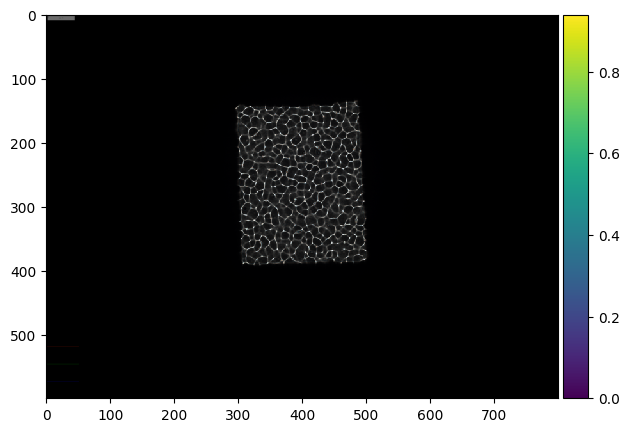

In [152]:
myim(FFT.psf,torch2np=True,colorbar=True)

In [77]:
#[i for i,f in enumerate(train_diffused_files) if f.name == 'r5681fb1ct.tiff']#

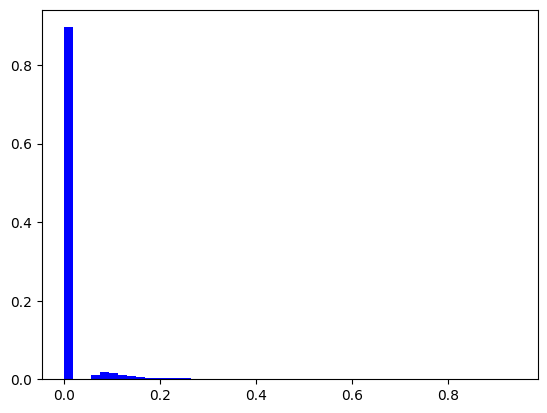

In [153]:
_=plot_hist(FFT.psf)

In [ ]:
#image_path = image_dir / 'cap' / 'binary_square_4_1080p_exp5_8bit.bmp'
image_path = image_dir / 'cap' / 'man_with_basket.bmp'
#image_path = image_dir /  'testimage_15_16bit_10g.bmp'

In [169]:
iw = FFT.forward_image_from_path(image_path,normlize=128)

[(<Axes: >, <Axes: >)]

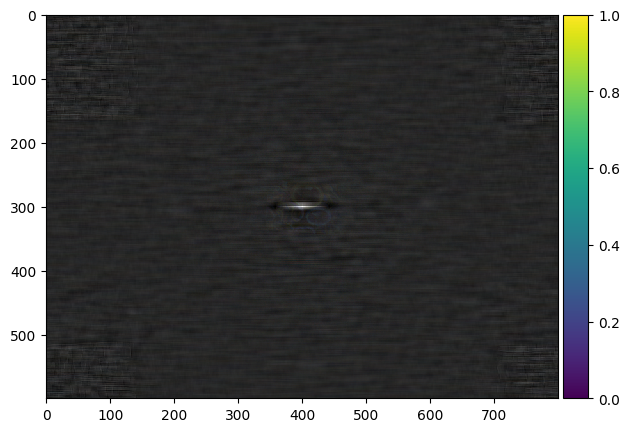

In [170]:
myim(FFT.fft_to_vis(iw),torch2np=True,colorbar=True)#,x_lim=(370,440),y_lim=(280,330))

In [78]:
train_diffused_files, train_gt_files, val_diffused_files, val_gt_files = get_files_list_from_dir(
                                        image_dir/ dataset_name ,suffix='.npy',randomize=False,
                                        diffused=diffused_dir,gt_tiff=gt_dir)
train_dataset = LenslessLearning(train_diffused_files, train_gt_files,
                        working_size=(args.image_height,args.image_width),
                        normalize=args.normalize_val)

In [79]:
d,gt,n=train_dataset[39]
d.shape,gt.shape,n

(torch.Size([3, 270, 480]), torch.Size([3, 270, 480]), 'im1411.npy')

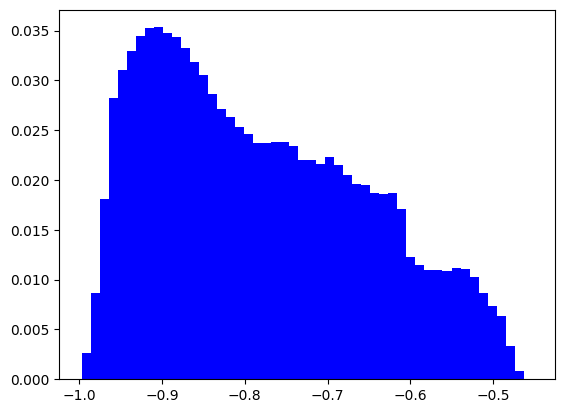

In [80]:
_=plot_hist(d)

In [81]:
weiner_d= FFT(d.unsqueeze(0))
weiner_d.shape
fft_output_vis = FFT.fft_to_vis(weiner_d)

In [82]:
d.shape,gt.shape,n

(torch.Size([3, 270, 480]), torch.Size([3, 270, 480]), 'im1411.npy')

[(<Axes: >, <Axes: >), (<Axes: >, <Axes: >)]

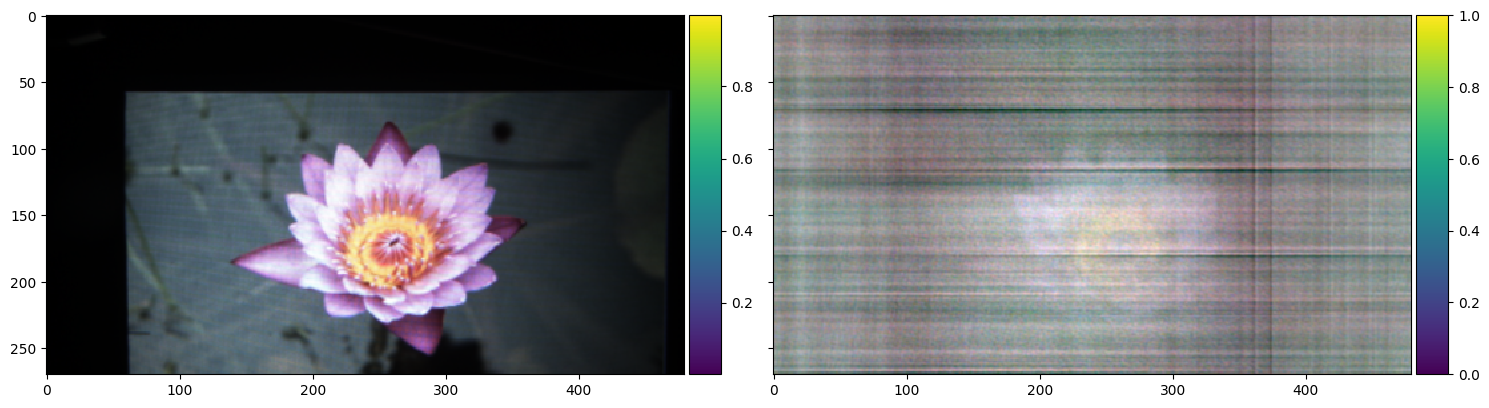

In [83]:
myim(gt*0.5+0.5,fft_output_vis,torch2np=True,colorbar=True,
            figsize=(15,20))

[(<Axes: >, <Axes: >), (<Axes: >, <Axes: >), (<Axes: >, <Axes: >)]

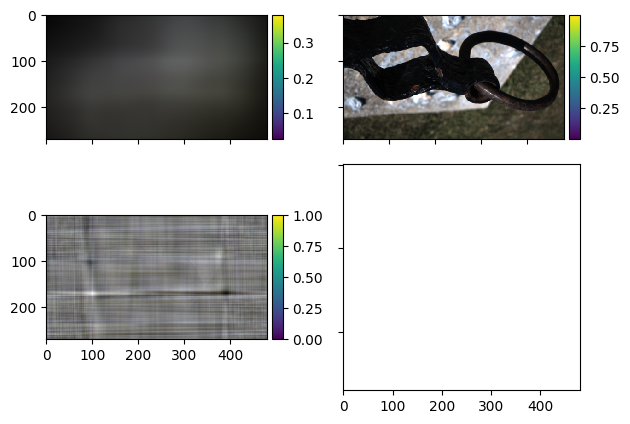

In [67]:
myim(d*0.5+0.5,gt*0.5+0.5,fft_output_vis,torch2np=True,colorbar=True)

In [13]:
if True:
    run = ex.run(config_updates={
                            'batch_size': 1,
                            "image_dir":"/mnt/extra/traning_datasets/lenless_simulated/diff_psf_zvi2_8bit/train",
                            #"image_dir":"/mnt/extra/traning_datasets/lenless_simulated/diffuser_images/train/",
                            #"image_dir":"/mnt/extra/traning_datasets/lensless/dataset",
                            #"image_dir":"/mnt/extra/traning_datasets/lenless_simulated/lenslet_cropped_padded/train",
                            #"image_dir":"/mnt/extra/traning_datasets/lenless_simulated/diffuser_0.4_bl_270/train",
                            #"psf_file_name":"psf.npy",
                            #"train_csv_filename":"dataset_train.csv",
                            #"val_csv_filename":"dataset_test.csv",
                            #"image_dir":"/mnt/extra/traning_datasets/lenless_simulated/diff_psf/",
                            #"simulated_dir": "/mnt/extra/traning_datasets/lensless/simulated/from_ido3/",
                            "test_set_path":"/mnt/rnd/Nadav/from_ido/Images_capure_in_the_lab/set_1",
                            "height":300,"width":400,
                            #"test_set_path":"/mnt/extra/traning_datasets/lensless/simulated/from_ido"
                            #"is_svd":True,
                            #"train_source_list":"/mnt/c/dev/lensless/phlatcam/imagenet/text_files/train_source_imagenet_384_384_Feb_19_debug.txt",
                            },
                            #named_configs=['ours_meas_1280_1408']
            )
else:
    run = ex.run(config_updates={
                            'batch_size': 1,
                            "image_dir":"/mnt/c/dev/lensless/diffuser_data/",
                            
                            #"image_dir":"/mnt/extra/traning_datasets/lensless/dataset",
                            #"test_set_path": "/mnt/c/Users/nadav.geva/scp/from_ido3/",
                            #"test_set_path":"test_image",
                            #"is_svd":True,
                            #"train_source_list":"/mnt/c/dev/lensless/phlatcam/imagenet/text_files/train_source_imagenet_384_384_Feb_19_debug.txt",
                            },
                            #named_configs=['ours_meas_1280_1408']
            )
args = tupperware(run.config)
args.image_dir = Path(args.image_dir)

WARNING - root - Changed type of config entry "image_dir" from PosixPath to str
WARNING - Train - No observers have been added to this run
INFO - Train - Running command 'notebook_main'
INFO - Train - Started
INFO - Train - Completed after 0:00:00


In [15]:
args.psf_width

400

In [10]:
data = get_dataloaders(args, is_local_rank_0=True)

INFO - root - Dataset: diffusercam Len Train: 12534 Val: 1394  Test: 6


In [11]:
FFT = FFTLayer_diff(args)


In [104]:
if False:
    FFT_tr = FFTLayer_diff(args)
    model_fft_folder = 'diffusercam/fft-diffusercam/20260428-124338'
    model_fft_path = f'/home/nadav/dev/PhoColens_Runs/SVDeconv/runs/{model_fft_folder}/ckpts/FFT_latest.pth'
    fft_ckpt = torch.load(model_fft_path, map_location=torch.device("cpu"))
    load_state_dict(FFT_tr, fft_ckpt["state_dict"])


In [146]:
FFT.psf.shape #, FFT_tr.psf.shape

torch.Size([3, 270, 480])

In [106]:
if False:
    images_path = '/mnt/extra/traning_datasets/lensless/dataset/diffuser_images/'
    tiff_path = f'{images_path}/im9.jpg.tiff'
    npy_path = f'{images_path}/im9.npy'
    tiff_test = '/mnt/extra/traning_datasets/lensless/dataset/test_image/hand.tiff'
    npy_im = np.load(npy_path)
    tiff_im = cv2.imread(tiff_path, -1).astype(np.float32)/4095.#  - 0.008273973
    tiff_im_test = cv2.imread(tiff_test, -1).astype(np.float32)/4095. # - 0.008273973
    tiff_im_test = cv2.resize(tiff_im_test, (480, 270))
    npy_im.shape,tiff_im.shape,tiff_im_test.shape
    _=plot_hist(tiff_im_test)

In [147]:
FFT.wiener_crop.shape

torch.Size([3, 270, 480])

[(<Axes: >, <Axes: >)]

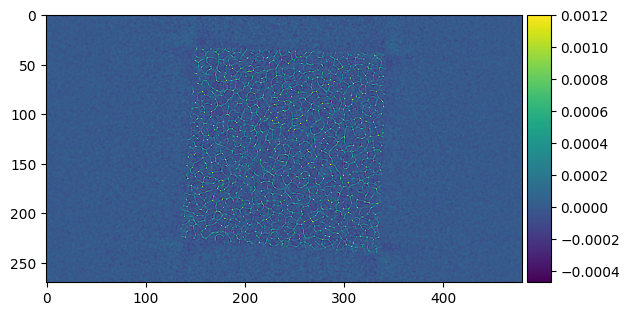

In [12]:
myim(FFT.wiener_crop.detach()[:1], #FFT_tr.wiener_crop.detach()[:1],
colorbar=True,torch2np=True,)#global_range=[-0.01,0.01])

[(<Axes: >, <Axes: >)]

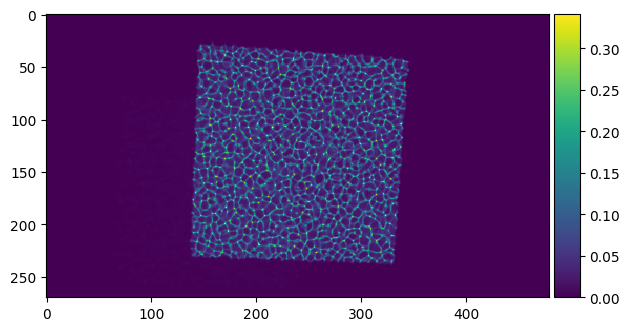

In [13]:
myim(FFT.psf[:1],colorbar=True,torch2np=True)

[(<Axes: >, <Axes: >)]

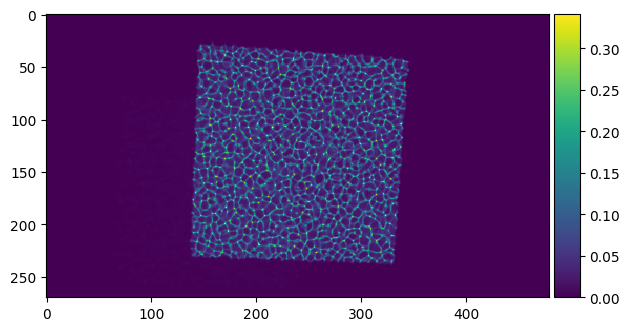

In [14]:
myim(FFT.psf[:1],colorbar=True,torch2np=True)

In [15]:
data.train_loader.dataset.ys[0].exists()

True

In [230]:
x,y,fname = data.train_loader.dataset[0]

In [231]:
x.dtype

torch.float32

In [35]:
data.train_loader.dataset.xs[0],data.train_loader.dataset.ys[0]#,data.train_loader.dataset.xs[0].shape,data.train_loader.dataset.ys[0].shape

(PosixPath('/mnt/extra/traning_datasets/lenless_simulated/diff_psf/fivek/diffused/a2534-JI2E3753.tiff'),
 PosixPath('/mnt/extra/traning_datasets/lenless_simulated/diff_psf/fivek/gt_tiff/a2534-JI2E3753.tiff'))

In [21]:
x = cv2.imread(data.train_loader.dataset.xs[0], -1)#.astype(np.float32)/4095.
y= cv2.imread(data.train_loader.dataset.ys[0], -1)#.astype(np.float32)/4095.

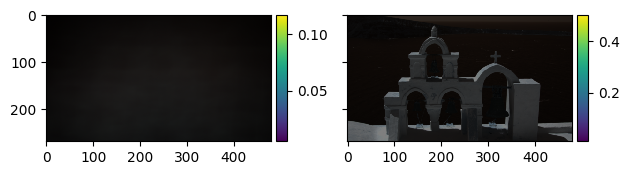

[(<Axes: >, <Axes: >), (<Axes: >, <Axes: >)]

In [31]:
myim(x/65535,y/65535,colorbar=True)

In [84]:
idl = iter(data.train_loader)

In [11]:
idl = iter(data.test_loader)

In [61]:
idl = iter(data.val_loader)

In [12]:
batch = next(idl)

In [13]:
source, target, filename = batch
#source = batch

In [14]:
source.shape,target.shape,filename

(torch.Size([1, 3, 300, 400]), torch.Size([1]), ('yellow_red_objects.bmp',))

In [22]:
source[0].min(),source.max()

(tensor(-1.), tensor(-0.9859))

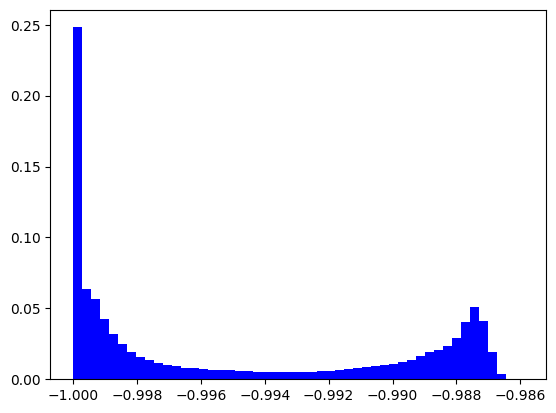

In [23]:
_=plot_hist(source[0])

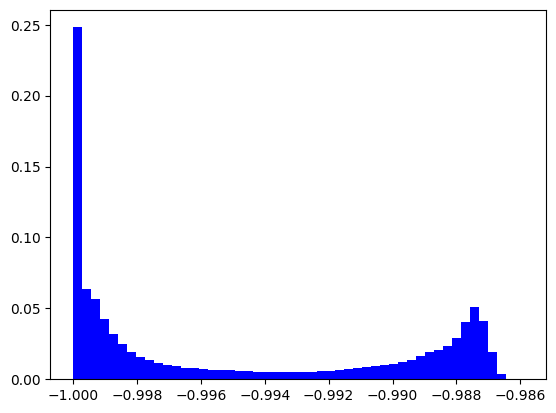

In [24]:
_=plot_hist(source[0])

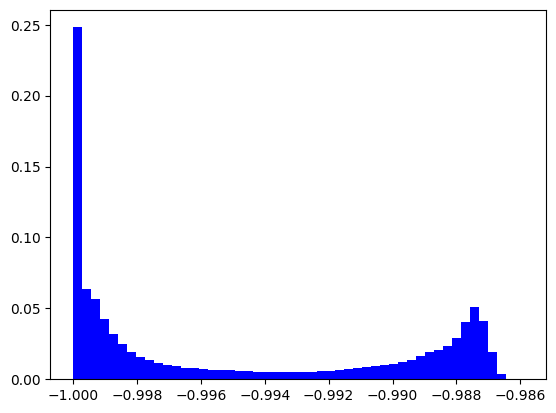

In [25]:
_=plot_hist(source[0])

[(<Axes: >, <Axes: >), (<Axes: >, <Axes: >)]

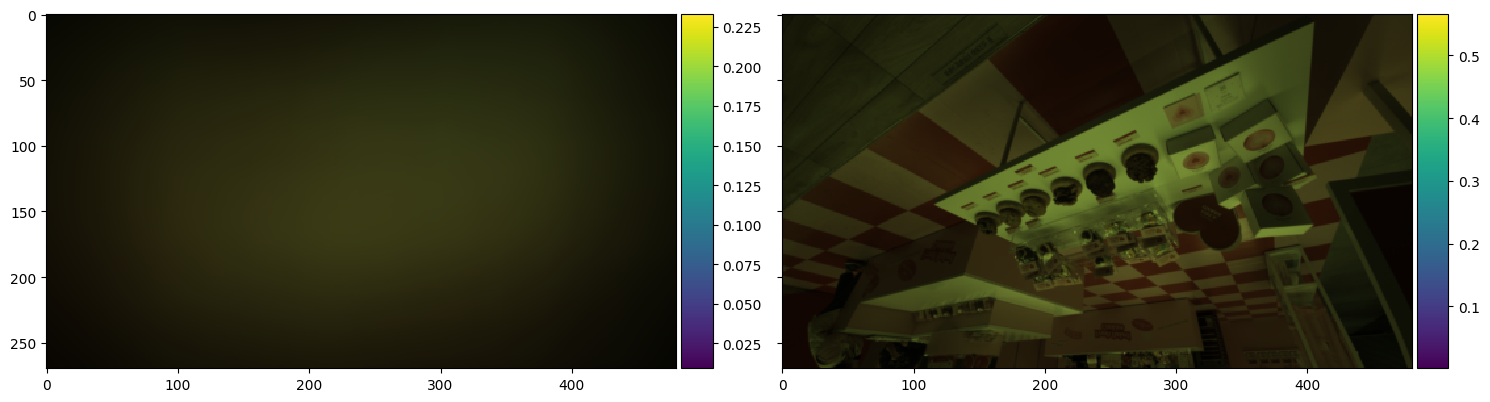

In [92]:
myim(source[0]*0.5+0.5,
    target[0]*0.5+0.5,
    torch2np=True,figsize=(15,30),colorbar=True)

In [26]:
fft_output = FFT(source)

In [27]:
fft_output.shape

torch.Size([1, 3, 270, 480])

In [28]:
fft_output_vis = fft_output[0].mul(0.5).add(0.5)
                

In [29]:
fft_output_vis.shape

torch.Size([3, 270, 480])

In [30]:
fft_output_vis = (fft_output_vis - fft_output_vis.min()) / (
                                fft_output_vis.max() - fft_output_vis.min()
                            )

In [ ]:
fft_output = FFT(source)
fft_output_vis = fft_output[0].mul(0.5).add(0.5)
fft_output_vis = (fft_output_vis - fft_output_vis.min()) / (
                                fft_output_vis.max() - fft_output_vis.min()
                            )

In [31]:
fft_output_vis.shape

torch.Size([3, 270, 480])

In [32]:
#cxhxw - > hxwxc 
#fft_output_vis = fft_output_vis.permute(1, 2, 0).cpu().detach().numpy()

In [33]:
myim(fft_output_vis.cpu().detach(),target[0]*0.5+0.5,
    #target[0]*0.5+0.5,
    torch2np=True,figsize=[10,20],)

ValueError: axes don't match array

[(<Axes: >, None)]

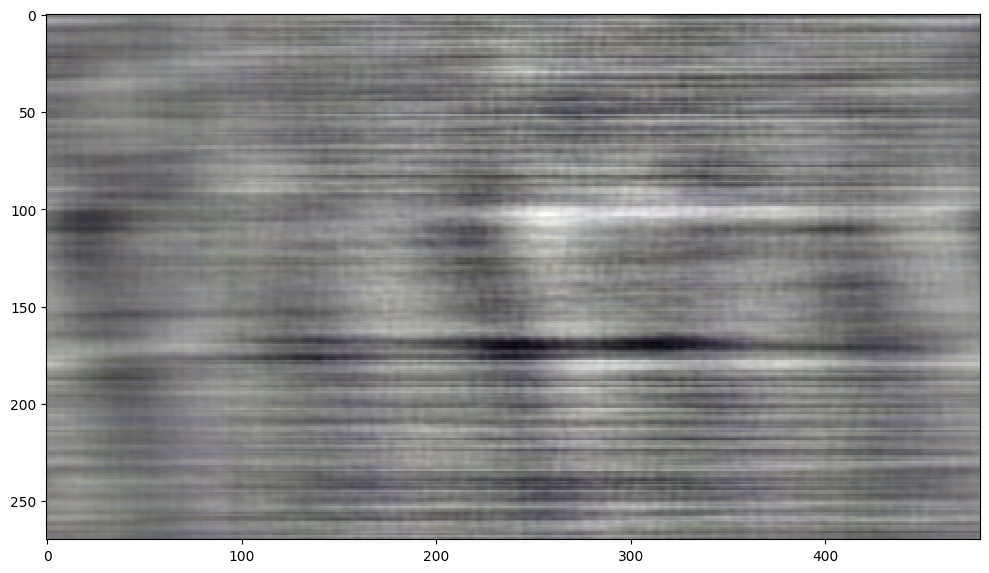

In [34]:
myim(fft_output_vis.cpu().detach(),
    #target[0]*0.5+0.5,
    torch2np=True,figsize=[10,20],)

In [57]:
fft_output_vis_val = fft_output_vis.permute(1, 2, 0).cpu().detach().numpy()


In [58]:
fft_output_vis_val.shape

(270, 480, 3)

In [59]:
cv2.imwrite(
        str('test_ffp.png'), (fft_output_vis_val[:, :, ::-1] * 255.0).astype(int)
)

[ WARN:0@1359.974] global loadsave.cpp:1089 imwrite_ Unsupported depth image for selected encoder is fallbacked to CV_8U.


True

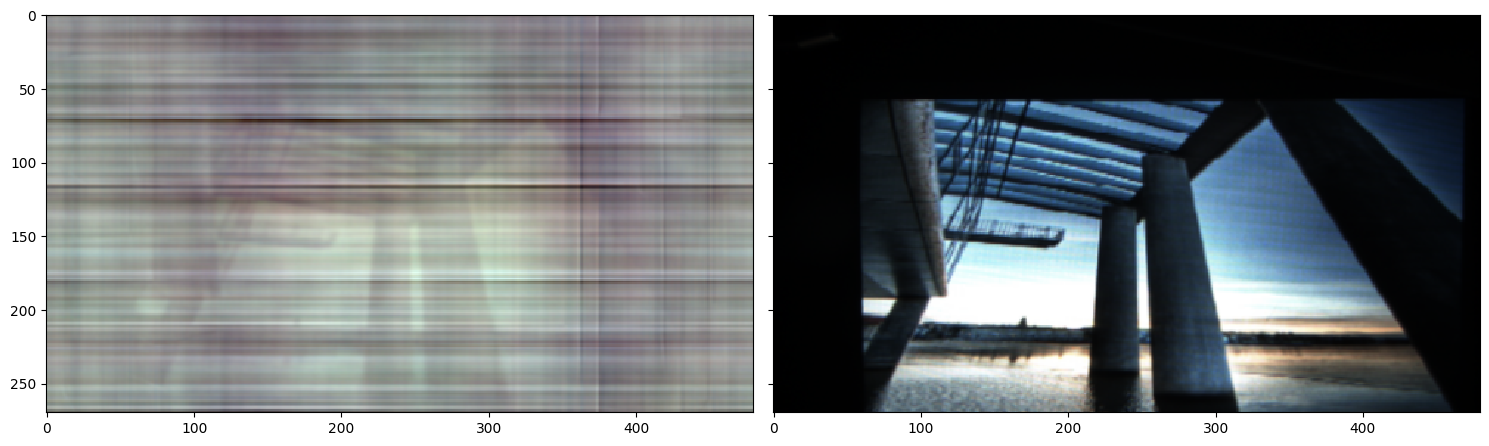

[(<Axes: >, None), (<Axes: >, None)]

In [61]:
myim(fft_output_vis.cpu().detach(),target[0]*0.5+0.5,
    torch2np=True,figsize=[15,30],)#x_lim=[150,300],y_lim=[100,200])

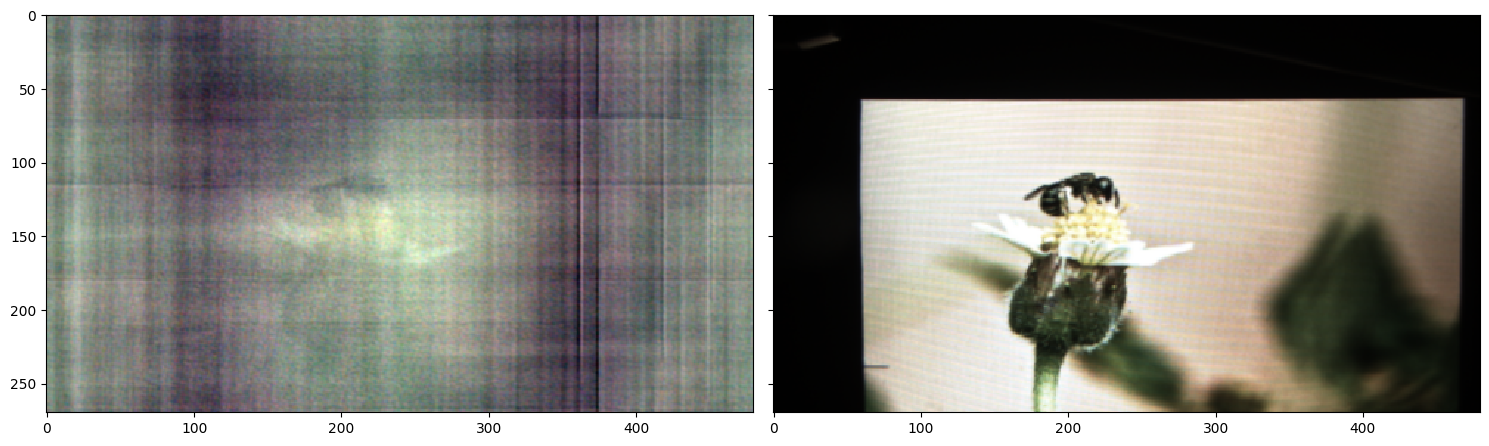

[(<Axes: >, None), (<Axes: >, None)]

In [ ]:
myim(fft_output_vis.cpu().detach(),target[0]*0.5+0.5,
    torch2np=True,figsize=[15,30],)

In [30]:
#plt.imshow(fft_output_vis)

In [31]:
FFT.wiener_crop.shape

torch.Size([3, 270, 480])

WARNING - matplotlib.image - Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.0011586925..0.003256618].


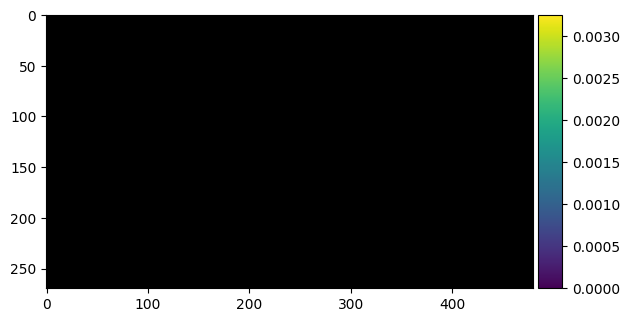

[(<Axes: >, <Axes: >)]

In [28]:
psf = FFT.wiener_crop.detach().cpu()#.numpy()
myim(psf,colorbar=True,torch2np=True,)#global_range=[0,0.1])

In [29]:
args.psf_mat

PosixPath('/mnt/c/dev/lensless/diffuser_data/psf.tiff')

In [30]:
#psf = load_psf(args.psf_mat)
psf  = np.array(Image.open(args.psf_mat))

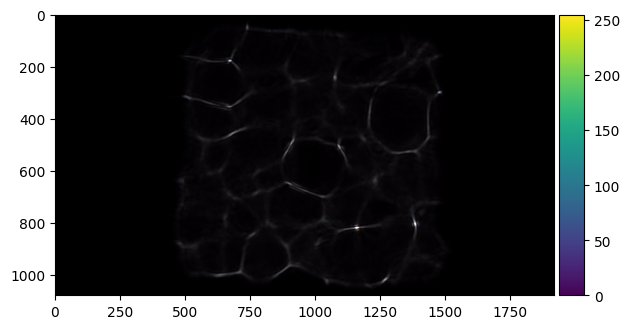

[(<Axes: >, <Axes: >)]

In [31]:
#plt.imshow(psf)
#myim(psf,colorbar=True,torch2np=True,global_range=[0,0.0000001])
myim(psf,colorbar=True,torch2np=False,global_range=[None,None])

In [13]:
from models.fftlayer_diff import load_psf

In [265]:
psf_path1 = Path('/mnt/extra/traning_datasets/lenless_simulated/Duck_tape_adj_270/train/psf.npy')
psf_path2 = Path('/mnt/extra/traning_datasets/lenless_simulated/diffuser_images/train/psf.tiff')

In [12]:
psf_path3 = Path('/mnt/rnd/Research/Lenless/psf_lab set up/sequence_15.6/psf15.6_61 15-20-10-322.bmp')


In [277]:
psf1 = load_psf(psf_path1)
psf2 = load_psf(psf_path2)

In [275]:
psf1 = np.load(psf_path1)#.astype(np.float32)
psf2 = np.array(Image.open(psf_path2))

In [13]:
psf3 = load_psf(psf_path3)

In [14]:
psf3.shape

torch.Size([3, 300, 400])

[(<Axes: >, <Axes: >)]

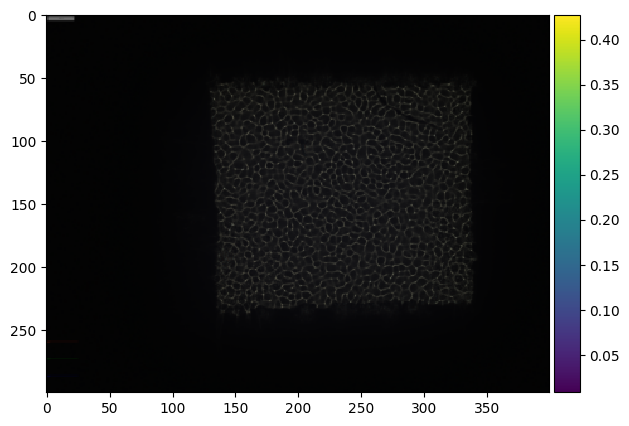

In [20]:
myim(psf3,colorbar=True,torch2np=True)

In [15]:
args.psf_mat = psf_path3

In [16]:
FFT = FFTLayer_diff(args)

WARNING - matplotlib.image - Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.00070605415..0.001447255].


[(<Axes: >, None), (<Axes: >, None)]

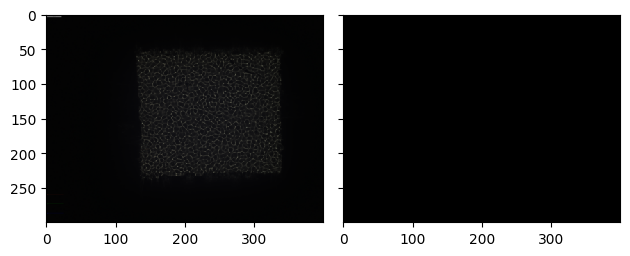

In [17]:
myim(FFT.psf,FFT.wiener_crop.detach(),torch2np=True)

In [39]:
#args.psf_centre_x, args.psf_crop_size_x
args.psf_centre_y , args.psf_crop_size_y // 2
240


240

In [35]:
FFT.wiener_crop.shape , FFT.psf_height

(torch.Size([3, 270, 400]), 270)

In [18]:
data = get_dataloaders(args, is_local_rank_0=True)

INFO - root - Dataset: diffusercam Len Train: 12534 Val: 1394  Test: 6


In [19]:
idl = iter(data.test_loader)

In [20]:
source,target,fname = next(idl)

In [21]:
source.shape

torch.Size([1, 3, 300, 400])

In [25]:
fft_output = FFT(source)#FFT(psf3.unsqueeze(0))


In [27]:
#fft_output = FFT(source)#FFT(psf3.unsqueeze(0))
fft_output_vis = fft_output[0].mul(0.5).add(0.5)
fft_output_vis = (fft_output_vis - fft_output_vis.min()) / (
                                fft_output_vis.max() - fft_output_vis.min()
                            )
fft_output_vis = fft_output_vis.detach()

In [28]:
fft_output.shape

torch.Size([1, 3, 300, 400])

In [47]:
fft_output_vis.shape

torch.Size([3, 270, 40])

[(<Axes: >, None)]

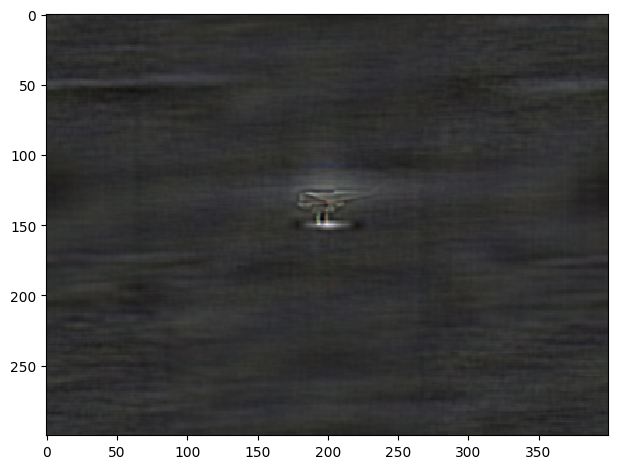

In [29]:
myim(fft_output_vis,torch2np=True)

In [278]:
psf1.min(),psf1.max(),psf2.min(),psf2.max()

(tensor(0.), tensor(229.2164), tensor(0.), tensor(0.9525))

WARNING - matplotlib.image - Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..229.21645].


[(<Axes: >, <Axes: >)]

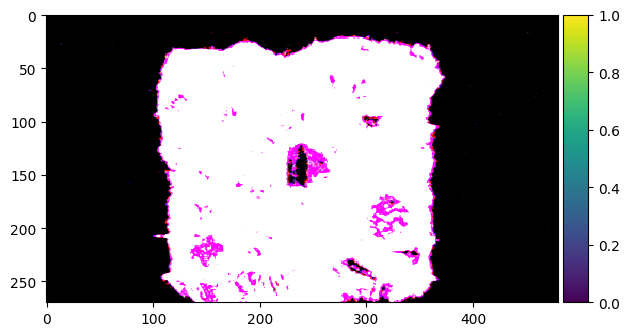

In [268]:
myim(psf1,colorbar=True,torch2np=True,global_range=[None,None])